# Excercise Week 1

## Import data
Move the file `wildschwein_BE.csv` into your project directory and import it into r as a **data.frame**. Assign correct column types as necessary and make sure the time zone is set correctly for the date/time column.

In [26]:
library(tidyverse)

In [27]:
wildschweine <- read_delim("Data/wildschwein_BE.csv")

Rows: 51246 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): TierID, TierName
dbl  (3): CollarID, Lat, Long
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [28]:
head(wildschweine)
# Datetime is corrextly set (dttm)
# column types: change TierID & CollarID into a factor

TierID,TierName,CollarID,DatetimeUTC,Lat,Long
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>
002A,Sabi,12275,2014-08-22 21:00:12,46.99317,7.049618
002A,Sabi,12275,2014-08-22 21:15:16,46.99416,7.049509
002A,Sabi,12275,2014-08-22 21:30:43,46.99383,7.049406
002A,Sabi,12275,2014-08-22 21:46:07,46.99375,7.049217
002A,Sabi,12275,2014-08-22 22:00:22,46.99375,7.049359
002A,Sabi,12275,2014-08-22 22:15:10,46.99382,7.049363


In [29]:
wildschweine$TierID <- as.factor(wildschweine$TierID)
wildschweine$CollarID <- as.factor(wildschweine$CollarID)

In [30]:
str(wildschweine)

spc_tbl_ [51,246 × 6] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ TierID     : Factor w/ 3 levels "002A","016A",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ TierName   : chr [1:51246] "Sabi" "Sabi" "Sabi" "Sabi" ...
 $ CollarID   : Factor w/ 3 levels "12275","13972",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ DatetimeUTC: POSIXct[1:51246], format: "2014-08-22 21:00:12" "2014-08-22 21:15:16" ...
 $ Lat        : num [1:51246] 47 47 47 47 47 ...
 $ Long       : num [1:51246] 7.05 7.05 7.05 7.05 7.05 ...
 - attr(*, "spec")=
  .. cols(
  ..   TierID = col_character(),
  ..   TierName = col_character(),
  ..   CollarID = col_double(),
  ..   DatetimeUTC = col_datetime(format = ""),
  ..   Lat = col_double(),
  ..   Long = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


## Explore Data
We will use a range of different visualization tools (i.e. R-packages) in this course. Several packages techniques have emerged in recent years, each with their specific strengths and weaknesses. While base::plot()is quick and simple, it not very scalable with growing complexity. **ggplot2** offers solutions for most use cases and has an elegant, consistent syntax that is easy to get accustomed to. We will get to know other techniques later in the course.

Get an overview of your data by creating a first “map-like” plot of your data producing a simple **scatter plot** with ggplot2. Setting up a ggplot with our data is done using the command `ggplot(wildschwein_BE, aes(Long, Lat, colour = TierID))`. Creating a map is done via the basic scatter plot command `geom_point()`.

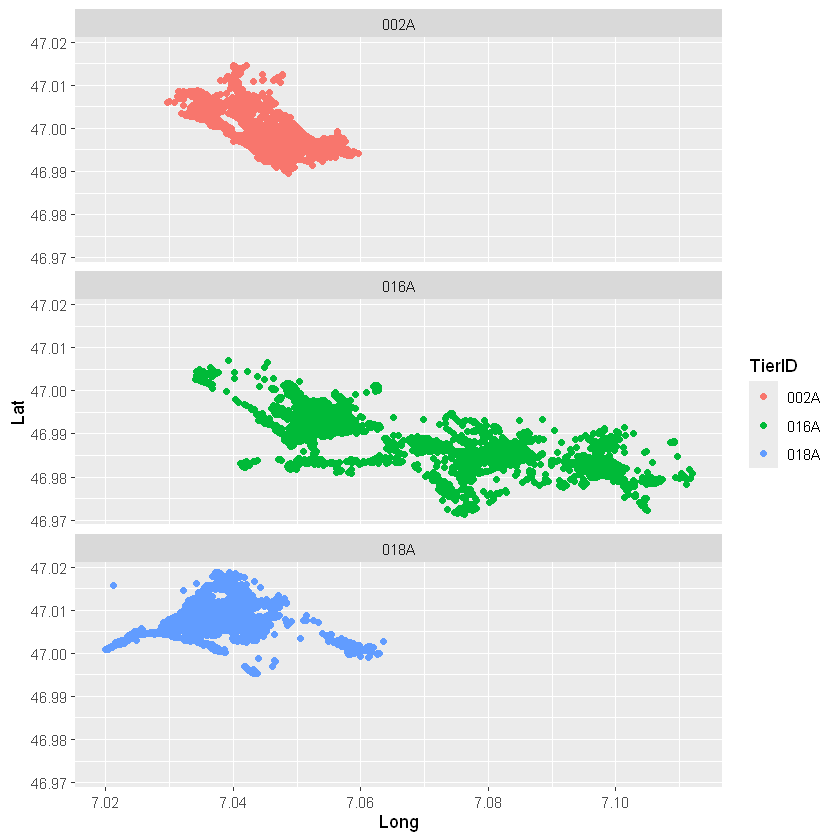

In [31]:
ggplot(wildschweine, aes(Long, Lat, colour = TierID)) +
    geom_point() +
    facet_wrap("TierID", ncol = 1)

## Convert data.frame into spatial object
Until now, we’ve stored our location data within data frames as Lat/Long columns. This works well for many tasks, but sometimes we need special spatial classes to handle our trajectories. We will get to know such cases in our next tasks, but first we need to **convert our data.frame into a spatial object**.

We will largely rely on `sf` when working with vector data in R. In order to transform our data.frame into an sf object, we need to use the function `st_as_sf()` while specifying the columns storing the coordinates and the coordinate reference system.

In [32]:
library(sf)

In [33]:
wildschweine_sf <- st_as_sf(wildschweine,
    coords = c("Long", "Lat"),
    crs = 4326)

Notice how `st_as_sf` takes the **EPSG code** for the `crs =` argument. You can find a lot of useful information on Coordinate Reference Systems (including EPSG Codes, etc.) under epsg.io.
Let’s compare our original data.frame with this new sf object:

In [34]:
head(wildschweine_sf)
head(wildschweine)

TierID,TierName,CollarID,DatetimeUTC,geometry
<fct>,<chr>,<fct>,<dttm>,<POINT [°]>
002A,Sabi,12275,2014-08-22 21:00:12,POINT (7.049618 46.99317)
002A,Sabi,12275,2014-08-22 21:15:16,POINT (7.049509 46.99416)
002A,Sabi,12275,2014-08-22 21:30:43,POINT (7.049406 46.99383)
002A,Sabi,12275,2014-08-22 21:46:07,POINT (7.049217 46.99375)
002A,Sabi,12275,2014-08-22 22:00:22,POINT (7.049359 46.99375)
002A,Sabi,12275,2014-08-22 22:15:10,POINT (7.049363 46.99382)


TierID,TierName,CollarID,DatetimeUTC,Lat,Long
<fct>,<chr>,<fct>,<dttm>,<dbl>,<dbl>
002A,Sabi,12275,2014-08-22 21:00:12,46.99317,7.049618
002A,Sabi,12275,2014-08-22 21:15:16,46.99416,7.049509
002A,Sabi,12275,2014-08-22 21:30:43,46.99383,7.049406
002A,Sabi,12275,2014-08-22 21:46:07,46.99375,7.049217
002A,Sabi,12275,2014-08-22 22:00:22,46.99375,7.049359
002A,Sabi,12275,2014-08-22 22:15:10,46.99382,7.049363


As you can see, `st_as_sf()` has **added some metadata to our dataframe** (Geometry type, Dimension, Bounding box, Geodetic CRS) and replaced the columns Lat and Long with a column named geometry. Other than that, the new sf object is very similar to our original dataframe. In fact, sf objects are essentially dataframes, as you can verify with the function `is.data.frame()`:

In [35]:
is.data.frame(wildschweine_sf)

[1] TRUE

All operations we know from handling data.frames can be used on the sf object. Try some out!

In [36]:
unique(wildschweine_sf$TierID)

[1] 002A 016A 018A
Levels: 002A 016A 018A

In [37]:
# subset rows
wildschweine_sf[3:7, ]
head(wildschweine_sf[wildschweine_sf$TierName != "Sabi", ])

TierID,TierName,CollarID,DatetimeUTC,geometry
<fct>,<chr>,<fct>,<dttm>,<POINT [°]>
002A,Sabi,12275,2014-08-22 21:30:43,POINT (7.049406 46.99383)
002A,Sabi,12275,2014-08-22 21:46:07,POINT (7.049217 46.99375)
002A,Sabi,12275,2014-08-22 22:00:22,POINT (7.049359 46.99375)
002A,Sabi,12275,2014-08-22 22:15:10,POINT (7.049363 46.99382)
002A,Sabi,12275,2014-08-22 22:30:13,POINT (7.049326 46.99387)


TierID,TierName,CollarID,DatetimeUTC,geometry
<fct>,<chr>,<fct>,<dttm>,<POINT [°]>
016A,Rosa,13972,2014-11-07 07:45:44,POINT (7.0493 46.9937)
016A,Rosa,13972,2014-11-07 08:00:10,POINT (7.049352 46.99379)
016A,Rosa,13972,2014-11-07 08:15:18,POINT (7.049162 46.99348)
016A,Rosa,13972,2014-11-07 08:30:23,POINT (7.049316 46.99385)
016A,Rosa,13972,2014-11-07 08:46:08,POINT (7.049318 46.99407)
016A,Rosa,13972,2014-11-07 09:00:11,POINT (7.049324 46.99411)


In [38]:
# subset colums
wildschweine_sf[5:10, 2:3]

TierName,CollarID,geometry
<chr>,<fct>,<POINT [°]>
Sabi,12275,POINT (7.049359 46.99375)
Sabi,12275,POINT (7.049363 46.99382)
Sabi,12275,POINT (7.049326 46.99387)
Sabi,12275,POINT (7.049237 46.99395)
Sabi,12275,POINT (7.048383 46.99481)
Sabi,12275,POINT (7.049396 46.99373)


## Remove unused data.frame

Instead of keeping the same data twice (once as a data.frame, and once as an sf object), we will **overwrite the data.frame and continue working with the sf object** from now on. This saves some memory space in R and avoids confusion.

In [39]:
wildschweine <- wildschweine_sf

remove(wildschweine_sf)
# we can remove this sf object, since it just eats up our memory

## Task 3: Reproject data
So what can we do with our new sf object that we couldn’t before? One example is **projecting the WGS84 (Lat/Long) coordinates into the new Swiss CRS CH1903+ LV951**. Do this by using the `function st_transform`.

By the way, do you notice a pattern here? The package sf names most functions for spatial operations with the prefix **`st_*`**, just as in PostGIS.

Here’s the resulting sf object from the operation. Note how the numeric values in the geometry column have changed.

In [40]:
# ... abfragen mit st_crs()
st_crs(wildschweine)

Coordinate Reference System:
  User input: EPSG:4326 
  wkt:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0

In [41]:
wildschweine <- st_transform(wildschweine, crs = 2056)

In [42]:
print(wildschweine)

Simple feature collection with 51246 features and 4 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 2568153 ymin: 1202306 xmax: 2575154 ymax: 1207609
Projected CRS: CH1903+ / LV95
# A tibble: 51,246 × 5
   TierID TierName CollarID DatetimeUTC                  geometry
 * <fct>  <chr>    <fct>    <dttm>                    <POINT [m]>
 1 002A   Sabi     12275    2014-08-22 21:00:12 (2570409 1204752)
 2 002A   Sabi     12275    2014-08-22 21:15:16 (2570402 1204863)
 3 002A   Sabi     12275    2014-08-22 21:30:43 (2570394 1204826)
 4 002A   Sabi     12275    2014-08-22 21:46:07 (2570379 1204817)
 5 002A   Sabi     12275    2014-08-22 22:00:22 (2570390 1204818)
 6 002A   Sabi     12275    2014-08-22 22:15:10 (2570390 1204825)
 7 002A   Sabi     12275    2014-08-22 22:30:13 (2570387 1204831)
 8 002A   Sabi     12275    2014-08-22 22:45:11 (2570381 1204840)
 9 002A   Sabi     12275    2014-08-22 23:00:27 (2570316 1204935)
10 002A   Sabi     12275    2014-08-22 23:15:41 (257

## Calculate Convex Hull (bbox)
Transforming from one Coordinate Reference System to another was one operation where we needed an object with a spatial nature. In this way, we were able to use an off-the-shelf function to project the coordinates from one CRS to another. In our next example, we again rely on a spatial function: We want to **calculate a convex hull per Wild boar**. And guess what the function for calculating a convex hull is called in sf? If you guessed `st_convex_hull()`, you were right!

By default `st_convex_hull()` calculates the **convex hull per feature**, i.e. per point in our dataset. This of course makes little sense. In order to calculate the convex hull per animal, we need to **convert our point- to multipoint-features** where each feature contains all positions of one animal. This is achieved in two steps:

- First: add a grouping variable to the sf object. Note the new grouping variable in the metadata of the sf object. Other than that, `group_by` has no effect on our sf object.
- Second: use `summarise()` to “union” all points into a multipoint object.

In [43]:
library("dplyr")

wildschweine_grouped <- wildschweine %>%
    group_by(TierID) %>%
    summarise()

wildschweine_grouped

TierID,geometry
<fct>,<MULTIPOINT [m]>
002A,MULTIPOINT ((2568903 120620...
016A,MULTIPOINT ((2569231 120582...
018A,MULTIPOINT ((2568153 120561...


Now we can run `st_convex_hull` on the new sf object.

In [44]:
mcp <- st_convex_hull(wildschweine_grouped)
mcp

,TierID,geometry
,<fct>,<POLYGON [m]>
1,002A,"POLYGON ((2570327 1204342, ..."
2,016A,"POLYGON ((2572419 1202306, ..."
3,018A,"POLYGON ((2569966 1204982, ..."


## Ploting spatial objects
Using `base plot` to visualize sf objects is easy enough, just try the following code.

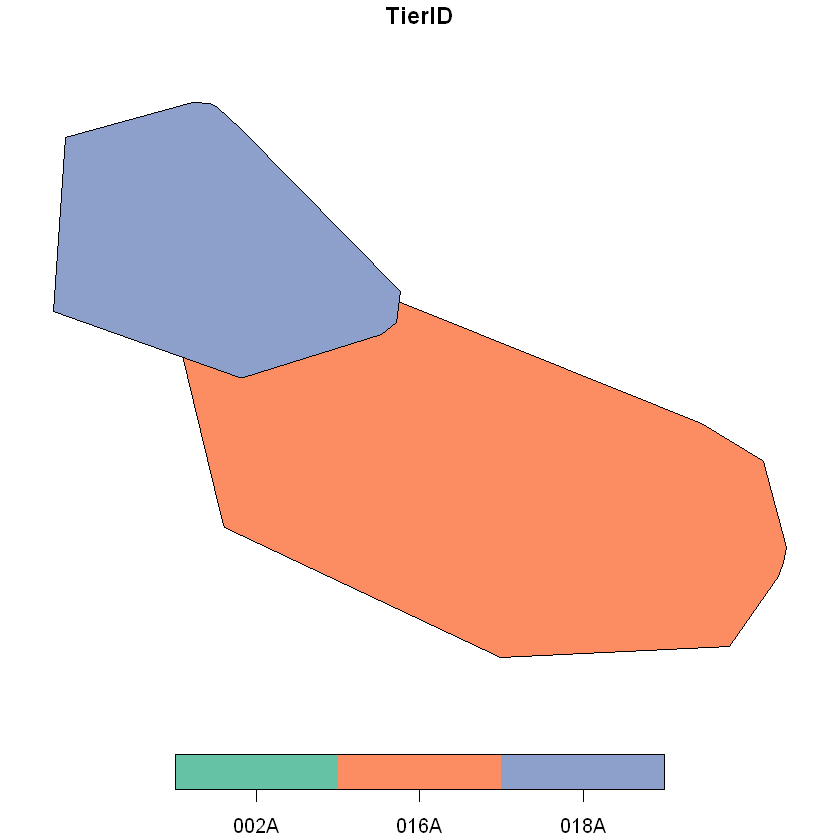

In [45]:
plot(mcp)

One wild boar is seems to be hidden by one of the others. Try and plot the object mcp with `ggplot`, setting the layer’s **alpha**

Note: ggplot refuses to use our specified CRS, so we need to force this by specifying `datum =` in `coord_sf()`. Try it out.

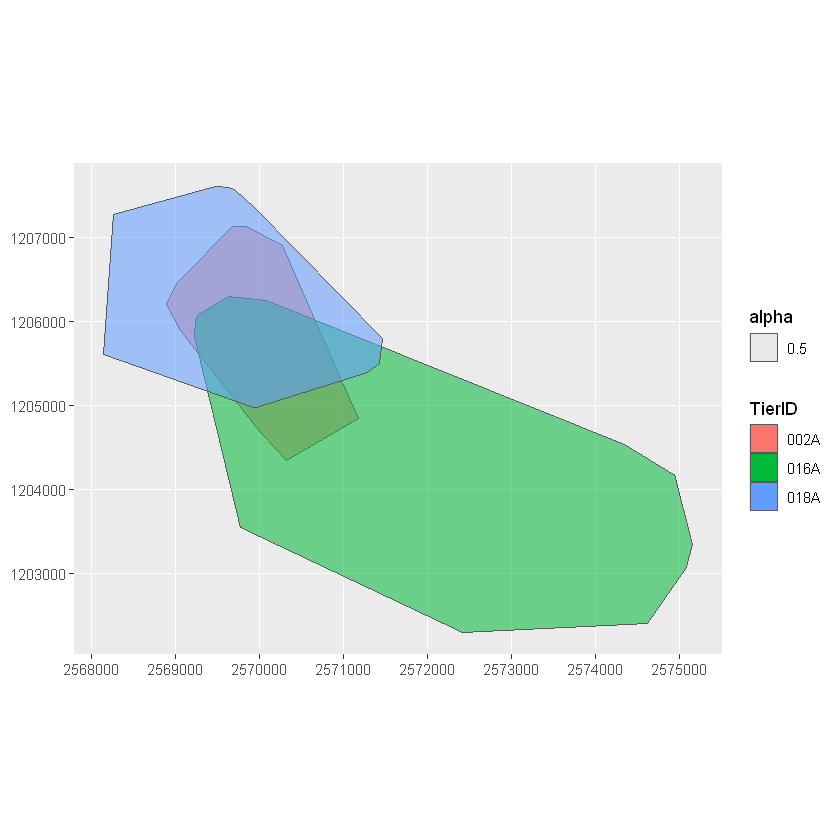

In [46]:
ggplot()  +
    geom_sf(data = mcp, aes(fill = TierID, alpha = 0.5)) +
            coord_sf(datum = 2056)

## Making maps with tmap
Let’s get to know a completely different package for creating maps: **`tmap`** (“thematic map”). This package was developed with a syntax very similar to ggplot2, which makes it easy to learn.

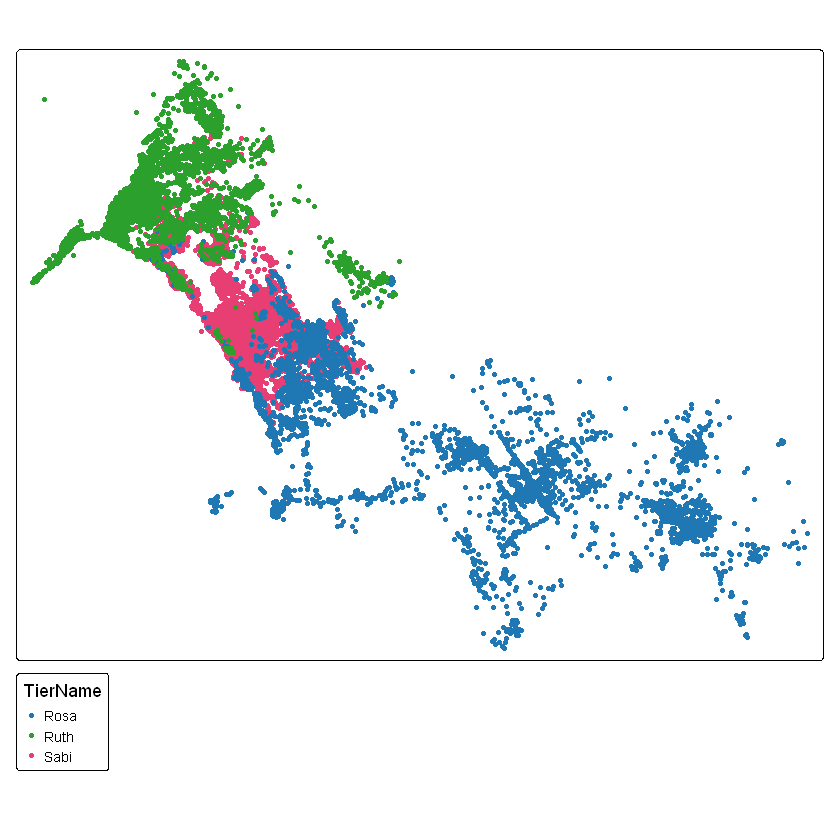

In [47]:
library("tmap")

tm_shape(wildschweine) +
    tm_dots(fill = "TierName")

As you can see, plotting layers in tmap is combined with the `+` sign, just as in ggplot2. In tmap however, **each layer consists of two objects**: a `tm_shape()` in which the data is called, and a `tm_*` object in which we define how the data is visualized (`tm_dots()` states that it is plotted as a point layer).

Add the object mcp to the plot in this manner. Checkout the [tmap website](https://r-tmap.github.io/tmap/) if you are having trouble.

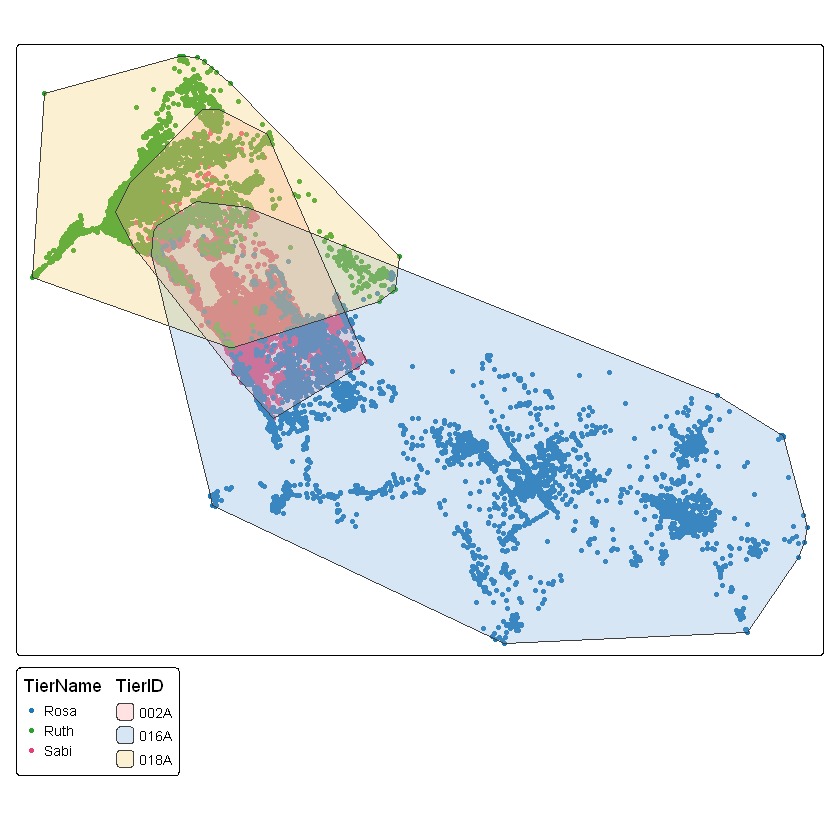

In [48]:
tm_shape(wildschweine) +
    tm_dots(fill = "TierName") +
tm_shape(mcp) + 
    tm_polygons(fill = "TierID", fill_alpha = 0.3)

## Create an interactive map
Rerun the `tmap()`... command from the previous task, but switch the plotting mode to “view”” `(tmap_mode("view"))` beforehand.

In [49]:
tmap_mode("view")

m <- tm_shape(wildschweine) +
    tm_dots(fill = "TierName") +
    tm_shape(mcp) + 
    tm_polygons(fill = "TierID", fill_alpha = 0.3)

print(tmap_leaflet(m))

ℹ tmap modes "plot" - "view"
ℹ toggle with `tmap::ttm()`
This message is displayed once per session.
Registered S3 method overwritten by 'jsonify':
  method     from    
  print.json jsonlite



In [50]:
tmap_save(m, "Week_1_Karte.html")

Interactive map saved to C:\Users\vikto\1 MeinJupyter\1 Master\Patterns & Trends\Week_1_Karte.html



Mit Rechtsklick auf die Karte --> "Open in new Browser Tab"